In [1]:
import math
from inspect import isfunction
from functools import partial

%matplotlib inline
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from einops import rearrange, reduce
from einops.layers.torch import Rearrange

import torch
from torch import nn, einsum
import torch.nn.functional as F
import numpy as np

D:\Anaconda\envs\torchenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


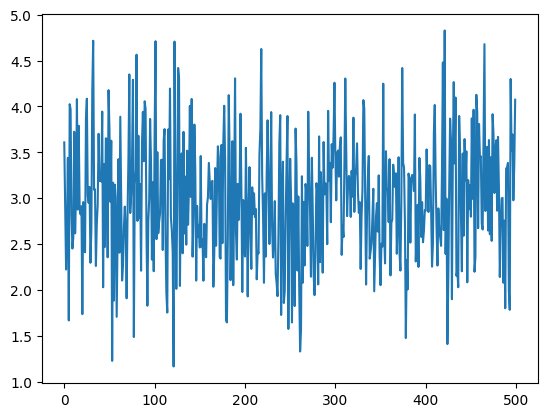

In [8]:
# mandatory task 1
# 1 create different Gaussiann noise with m and v
m = 3.0
q = 0.5
num_trajectories = 500
x0 = np.random.normal(loc=m, scale=np.sqrt(q), size=num_trajectories)

plt.plot(x0)



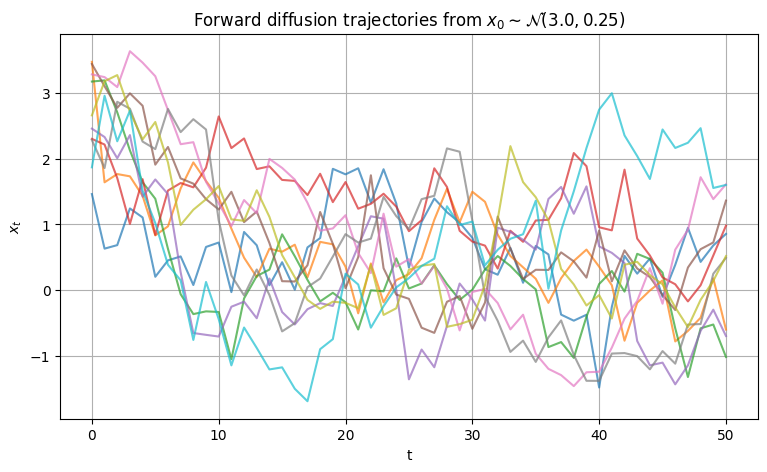

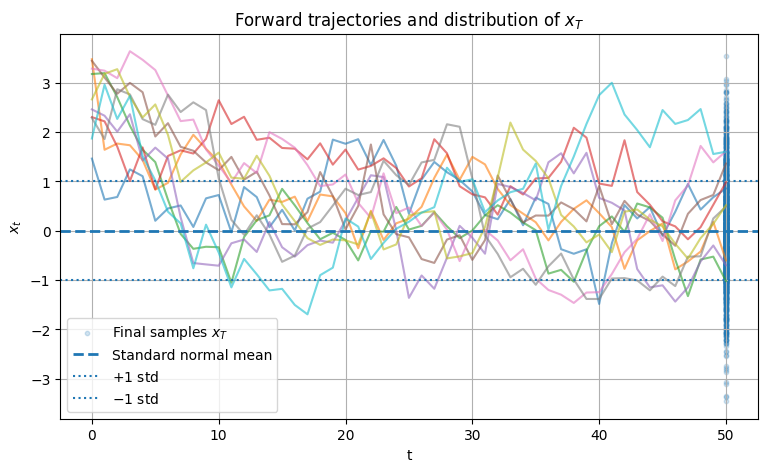

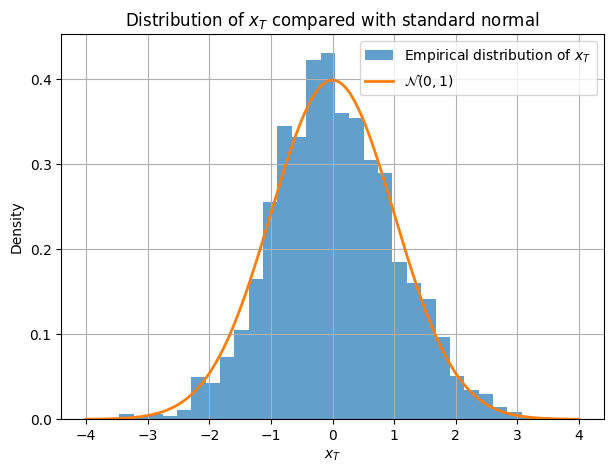

Mean of x0: 2.987687055503052
Variance of x0: 0.46076498981076885
Mean of x_T: 0.03102371022350311
Variance of x_T: 1.0022539478207242


In [19]:
# forward process
import numpy as np
import matplotlib.pyplot as plt

# diffusion settings
T = 50
beta = 0.25
num_trajectories = 2000   # at least 100

# store all trajectories
xs = np.zeros((num_trajectories, T + 1))

# sample different x0 values
xs[:, 0] = np.random.normal(
    loc=m,
    scale=np.sqrt(q),
    size=num_trajectories
)

# forward diffusion
for t in range(1, T + 1):
    noise = np.random.normal(0, 1, size=num_trajectories)

    xs[:, t] = (
        np.sqrt(1 - beta) * xs[:, t - 1]
        + np.sqrt(beta) * noise
    )
x_T = xs[:, T]
plt.figure(figsize=(9, 5))

# Plot only a few trajectories, otherwise the figure becomes messy
for i in range(10):
    plt.plot(
        range(T + 1),
        xs[i, :],
        alpha=0.7
    )

plt.xlabel("t")
plt.ylabel(r"$x_t$")
plt.title(r"Forward diffusion trajectories from $x_0 \sim \mathcal{N}(3.0, 0.25)$")
plt.grid(True)
plt.show()

# ============================================================
# 6. Show final x_T samples on the x_t against t plot
# ============================================================

plt.figure(figsize=(9, 5))

# Plot a few trajectories
for i in range(10):
    plt.plot(
        range(T + 1),
        xs[i, :],
        alpha=0.6
    )

# Plot all final samples x_T as a vertical cloud at t = T
plt.scatter(
    np.full(num_trajectories, T),
    xs[:, T],
    s=10,
    alpha=0.2,
    label=r"Final samples $x_T$"
)

plt.axhline(0, linestyle="--", linewidth=2, label="Standard normal mean")
plt.axhline(1, linestyle=":", linewidth=1.5, label=r"$+1$ std")
plt.axhline(-1, linestyle=":", linewidth=1.5, label=r"$-1$ std")

plt.xlabel("t")
plt.ylabel(r"$x_t$")
plt.title(r"Forward trajectories and distribution of $x_T$")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 7. Histogram of x_T to verify approximately standard normal
# ============================================================

x_T = xs[:, T]

plt.figure(figsize=(7, 5))

plt.hist(
    x_T,
    bins=30,
    density=True,
    alpha=0.7,
    label=r"Empirical distribution of $x_T$"
)

# Standard normal density curve
z = np.linspace(-4, 4, 300)
standard_normal_pdf = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * z**2)

plt.plot(
    z,
    standard_normal_pdf,
    linewidth=2,
    label=r"$\mathcal{N}(0, 1)$"
)

plt.xlabel(r"$x_T$")
plt.ylabel("Density")
plt.title(r"Distribution of $x_T$ compared with standard normal")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 8. Numerical verification
# ============================================================

print("Mean of x0:", np.mean(xs[:, 0]))
print("Variance of x0:", np.var(xs[:, 0]))

print("Mean of x_T:", np.mean(x_T))
print("Variance of x_T:", np.var(x_T))

In [20]:

# Constant beta schedule
betas = np.full(T + 1, beta)
# index 0 unused, so beta_t = betas[t]

alphas = 1.0 - betas

# alpha_bar[t] = alpha_1 * alpha_2 * ... * alpha_t
alpha_bars = np.ones(T + 1)
for t in range(1, T + 1):
    alpha_bars[t] = alpha_bars[t - 1] * alphas[t]
def reverse_posterior_mean_variance(x_t, x_0, t, betas, alphas, alpha_bars):
    """
    Compute q(x_{t-1} | x_t, x_0).

    Returns:
        mean: posterior mean
        var: posterior variance
    """

    beta_t = betas[t]
    alpha_t = alphas[t]
    alpha_bar_t = alpha_bars[t]
    alpha_bar_prev = alpha_bars[t - 1]

    coef_x0 = (
        np.sqrt(alpha_bar_prev) * beta_t
        / (1.0 - alpha_bar_t)
    )

    coef_xt = (
        np.sqrt(alpha_t) * (1.0 - alpha_bar_prev)
        / (1.0 - alpha_bar_t)
    )

    mean = coef_x0 * x_0 + coef_xt * x_t

    var = (
        (1.0 - alpha_bar_prev)
        / (1.0 - alpha_bar_t)
        * beta_t
    )

    return mean, var
def sample_reverse_step(x_t, x_0, t, betas, alphas, alpha_bars):
    """
    Sample x_{t-1} from q(x_{t-1} | x_t, x_0).
    """

    mean, var = reverse_posterior_mean_variance(
        x_t, x_0, t, betas, alphas, alpha_bars
    )

    noise = np.random.normal(0.0, 1.0, size=np.shape(x_t))

    x_prev = mean + np.sqrt(var) * noise

    return x_prev


In [21]:
print(xs.shape)
print(x_T.shape)

(2000, 51)
(2000,)


100%|██████████| 50/50 [00:00<?, ?it/s]

2.987687055503052
0.46076498981076885
2.987687055503052
0.46076498981076885


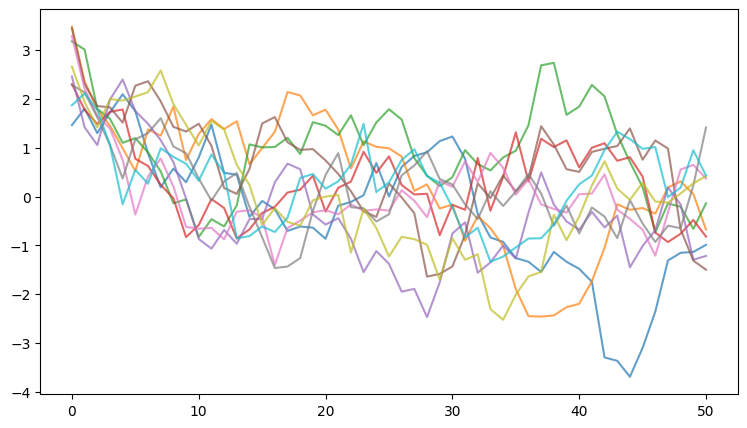

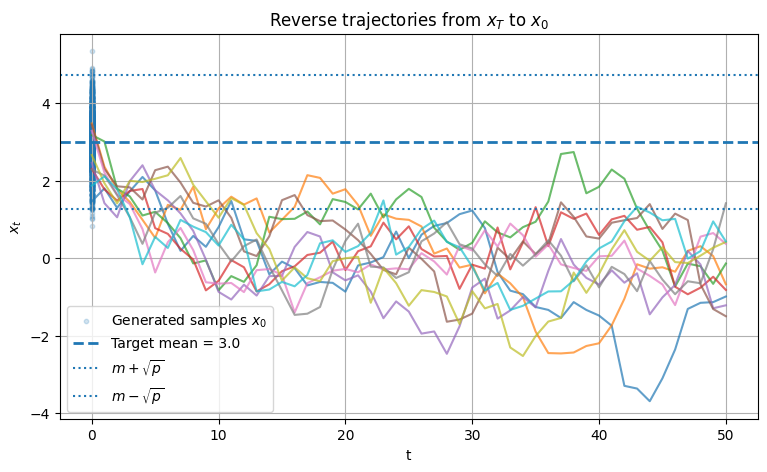

In [34]:


reverse_samples = np.zeros((num_trajectories, T + 1))

x0_known = xs[:, 0]
reverse_samples[:, T] = np.random.normal(0, 1, size=num_trajectories)

for t in tqdm(range(T, 0, -1)):
    reverse_samples[:, t - 1] = sample_reverse_step(
        reverse_samples[:, t],
        x0_known,
        t,
        betas,
        alphas,
        alpha_bars
    )
print(np.mean(reverse_samples[:, 0]))
print(np.var(reverse_samples[:, 0]))
print(np.mean(x0_known))
print(np.var(x0_known))

plt.figure(figsize=(9, 5))

for i in range(10):
    plt.plot(range(T + 1), reverse_samples[i, :], alpha=0.7)

plt.figure(figsize=(9, 5))

for i in range(10):
    plt.plot(range(T + 1), reverse_samples[i, :], alpha=0.7)

# show generated x0 distribution at t = 0
plt.scatter(
    np.full(num_trajectories, 0),
    reverse_samples[:, 0],
    s=10,
    alpha=0.2,
    label=r"Generated samples $x_0$"
)

# target distribution reference lines
target_mean = m
target_std = np.sqrt(q)

plt.axhline(target_mean, linestyle="--", linewidth=2, label=rf"Target mean = {target_mean}")
plt.axhline(target_mean + target_std, linestyle=":", linewidth=1.5, label=rf"$m+\sqrt{{q}}$")
plt.axhline(target_mean - target_std, linestyle=":", linewidth=1.5, label=rf"$m-\sqrt{{q}}$")

plt.xlabel("t")
plt.ylabel(r"$x_t$")
plt.title(r"Reverse trajectories from $x_T$ to $x_0$")
plt.legend()
plt.grid(True)
plt.show()

In [2]:
# mandatory task 2
import torch
from torch import nn
from torch.nn import functional as F


class SinusoidalEmbedding(nn.Module):
    def __init__(self, size: int, scale: float = 1.0):
        super().__init__()
        self.size = size
        self.scale = scale

    def forward(self, x: torch.Tensor):
        x = x * self.scale
        half_size = self.size // 2
        emb = torch.log(torch.Tensor([10000.0])) / (half_size - 1)
        emb = torch.exp(-emb * torch.arange(half_size))
        emb = x.unsqueeze(-1) * emb.unsqueeze(0)
        emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=-1)
        return emb

    def __len__(self):
        return self.size

In [21]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader


DATASET_PATHS = {
    "circle": "MandatoryTask2/circle_pts.npy",
    "dinohead": "MandatoryTask2/dinohead_pts.npy",
    "square": "MandatoryTask2/square_pts.npy",
}

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)



device: cpu


In [20]:
class SinusoidalEmbedding(nn.Module):
    """
    Sinusoidal embedding for either time steps or coordinates.

    For time:
        input shape:  (batch,)
        output shape: (batch, size)

    For coordinates:
        input shape:  (batch,)
        output shape: (batch, size)
    """

    def __init__(self, size: int, scale: float = 1.0):
        super().__init__()
        self.size = size
        self.scale = scale

    def forward(self, x: torch.Tensor):
        x = x * self.scale

        half_size = self.size // 2

        # Important: create tensors on the same device as x.
        freqs = torch.exp(
            -torch.log(torch.tensor(10000.0, device=x.device))
            * torch.arange(half_size, device=x.device)
            / (half_size - 1)
        )

        emb = x.unsqueeze(-1) * freqs.unsqueeze(0)
        emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=-1)

        return emb

    def __len__(self):
        return self.size


class NoisePredictor(nn.Module):
    """
    MLP epsilon_theta(x_t, t).

    Input:
        x_t: noisy 2D points, shape (batch, 2)
        t:   timestep indices, shape (batch,)

    Output:
        predicted raw Gaussian noise epsilon, shape (batch, 2)
    """

    def __init__(
        self,
        time_emb_dim: int = 64,
        coord_emb_dim: int = 32,
        hidden_dim: int = 128,
    ):
        super().__init__()

        self.time_embedding = SinusoidalEmbedding(time_emb_dim, scale=1.0)
        self.coord_embedding = SinusoidalEmbedding(coord_emb_dim, scale=10.0)

        input_dim = time_emb_dim + 2 * coord_emb_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x_t: torch.Tensor, t: torch.Tensor):
        t_emb = self.time_embedding(t.float())

        x_emb = self.coord_embedding(x_t[:, 0])
        y_emb = self.coord_embedding(x_t[:, 1])

        inp = torch.cat([x_emb, y_emb, t_emb], dim=1)
        return self.net(inp)


In [22]:
def load_points(file_path: str | Path) -> torch.Tensor:
    """
    Load one .npy point dataset.

    Expected shape:
        (num_points, 2)
    """

    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(
            f"Could not find {file_path}. "
            "Check that the MandatoryTask2 folder is in the same directory as this notebook."
        )

    points = np.load(file_path)

    if points.ndim != 2 or points.shape[1] != 2:
        raise ValueError(
            f"{file_path} should have shape (N, 2), but got {points.shape}."
        )

    points = torch.tensor(points, dtype=torch.float32)
    print(f"Loaded {file_path.name}: {tuple(points.shape)}")

    return points


def make_dataloader(points: torch.Tensor, batch_size: int = 64, shuffle: bool = True):
    dataset = TensorDataset(points)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def make_schedule(
    T: int = 300,
    beta_start: float = 1e-4,
    beta_end: float = 0.02,
    device: str = device,
):
    """
    Create the diffusion noise schedule.

    alpha_t = 1 - beta_t
    alpha_bar_t = product_{i=1}^{t} alpha_i
    """

    betas = torch.linspace(beta_start, beta_end, T, device=device)
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)

    schedule = {
        "T": T,
        "betas": betas,
        "alphas": alphas,
        "alpha_bars": alpha_bars,
        "sqrt_alpha_bars": torch.sqrt(alpha_bars),
        "sqrt_one_minus_alpha_bars": torch.sqrt(1.0 - alpha_bars),
    }

    print("alpha_bar_T =", alpha_bars[-1].item())
    return schedule


def q_sample(
    x0: torch.Tensor,
    t: torch.Tensor,
    noise: torch.Tensor,
    schedule: dict,
):
    """
    Sample x_t directly from q(x_t | x_0):

        x_t = sqrt(alpha_bar_t) x_0
              + sqrt(1 - alpha_bar_t) epsilon
    """

    sqrt_ab_t = schedule["sqrt_alpha_bars"][t].unsqueeze(1)
    sqrt_omab_t = schedule["sqrt_one_minus_alpha_bars"][t].unsqueeze(1)

    return sqrt_ab_t * x0 + sqrt_omab_t * noise


In [23]:
def train_noise_predictor(
    points: torch.Tensor,
    *,
    T: int = 300,
    beta_start: float = 1e-4,
    beta_end: float = 0.02,
    batch_size: int = 64,
    num_epochs: int = 5000,
    lr: float = 1e-3,
    time_emb_dim: int = 64,
    coord_emb_dim: int = 32,
    hidden_dim: int = 128,
    print_every: int = 500,
    device: str = device,
):
    """
    Train one diffusion noise-prediction model for one 2D point dataset.

    The model predicts the raw Gaussian noise epsilon used in q_sample.
    """

    points = points.to(device)
    dataloader = make_dataloader(points, batch_size=batch_size, shuffle=True)

    schedule = make_schedule(
        T=T,
        beta_start=beta_start,
        beta_end=beta_end,
        device=device,
    )

    model = NoisePredictor(
        time_emb_dim=time_emb_dim,
        coord_emb_dim=coord_emb_dim,
        hidden_dim=hidden_dim,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []

    for epoch in range(num_epochs):
        model.train()
        epoch_losses = []

        for (x0,) in dataloader:
            x0 = x0.to(device)
            batch_size_now = x0.shape[0]

            # Random timestep for each point in the batch.
            t = torch.randint(0, T, (batch_size_now,), device=device)

            # Raw standard Gaussian noise epsilon ~ N(0, I).
            noise = torch.randn_like(x0)

            # q_sample applies the time-dependent scaling.
            x_t = q_sample(x0, t, noise, schedule)

            # Model predicts raw epsilon, not the scaled noise.
            pred_noise = model(x_t, t)

            loss = F.mse_loss(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        mean_loss = float(np.mean(epoch_losses))
        loss_history.append(mean_loss)

        if epoch % print_every == 0:
            print(f"Epoch {epoch:5d}, loss = {mean_loss:.6f}")

    return model, schedule, loss_history


In [25]:
@torch.no_grad()
def sample_points(
    model: nn.Module,
    schedule: dict,
    *,
    num_samples: int = 1000,
    device: str = device,
):
    """
    Reverse diffusion sampling.

    Start from x_T ~ N(0, I), then repeatedly use the model prediction
    epsilon_theta(x_t, t) to move from x_t to x_{t-1}.
    """

    model.eval()

    T = schedule["T"]
    betas = schedule["betas"]
    alphas = schedule["alphas"]
    alpha_bars = schedule["alpha_bars"]

    x = torch.randn(num_samples, 2, device=device)

    for time_step in reversed(range(T)):
        t = torch.full(
            (num_samples,),
            time_step,
            device=device,
            dtype=torch.long,
        )

        pred_noise = model(x, t)

        alpha_t = alphas[time_step]
        beta_t = betas[time_step]
        alpha_bar_t = alpha_bars[time_step]

        coef = (1.0 - alpha_t) / torch.sqrt(1.0 - alpha_bar_t)
        mean = (1.0 / torch.sqrt(alpha_t)) * (x - coef * pred_noise)

        if time_step > 0:
            z = torch.randn_like(x)
            x = mean + torch.sqrt(beta_t) * z
        else:
            x = mean

    return x.cpu()


In [26]:
def plot_dataset_result(
    dataset_name: str,
    real_points: torch.Tensor,
    generated_points: torch.Tensor,
    loss_history: list[float],
):
    """
    Plot original points, generated points, and training loss.
    """

    real_np = real_points.detach().cpu().numpy()
    gen_np = generated_points.detach().cpu().numpy()

    plt.figure(figsize=(5, 5))
    plt.scatter(real_np[:, 0], real_np[:, 1], s=5)
    plt.axis("equal")
    plt.title(f"{dataset_name}: original data")
    plt.show()

    plt.figure(figsize=(5, 5))
    plt.scatter(gen_np[:, 0], gen_np[:, 1], s=5)
    plt.axis("equal")
    plt.title(f"{dataset_name}: generated samples")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel("epoch")
    plt.ylabel("MSE loss")
    plt.title(f"{dataset_name}: training loss")
    plt.grid(True)
    plt.show()


def run_one_dataset(
    dataset_name: str,
    file_path: str | Path,
    *,
    num_epochs: int = 5000,
    num_samples: int = 1000,
    batch_size: int = 64,
    T: int = 300,
    lr: float = 1e-3,
    plot: bool = True,
    device: str = device,
):
    """
    Complete pipeline for one dataset:

        load data -> train model -> sample generated points -> plot
    """

    print(f"\n========== {dataset_name} ==========")

    points = load_points(file_path)

    model, schedule, loss_history = train_noise_predictor(
        points,
        T=T,
        batch_size=batch_size,
        num_epochs=num_epochs,
        lr=lr,
        device=device,
    )

    generated = sample_points(
        model,
        schedule,
        num_samples=num_samples,
        device=device,
    )

    if plot:
        plot_dataset_result(dataset_name, points, generated, loss_history)

    return {
        "name": dataset_name,
        "points": points,
        "model": model,
        "schedule": schedule,
        "loss_history": loss_history,
        "generated": generated,
    }


def run_all_datasets(
    dataset_paths: dict[str, str | Path] = DATASET_PATHS,
    *,
    num_epochs: int = 5000,
    num_samples: int = 1000,
    batch_size: int = 64,
    T: int = 300,
    lr: float = 1e-3,
    plot: bool = True,
    device: str = device,
):
    """
    Run the same Mandatory Task 2 pipeline for circle, dinohead, and square.
    """

    results = {}

    for dataset_name, file_path in dataset_paths.items():
        results[dataset_name] = run_one_dataset(
            dataset_name,
            file_path,
            num_epochs=num_epochs,
            num_samples=num_samples,
            batch_size=batch_size,
            T=T,
            lr=lr,
            plot=plot,
            device=device,
        )

    return results



========== circle ==========
Loaded circle_pts.npy: (1000, 2)
alpha_bar_T = 0.04805843159556389
Epoch     0, loss = 0.965112
Epoch   500, loss = 0.484194
Epoch  1000, loss = 0.496037
Epoch  1500, loss = 0.479775
Epoch  2000, loss = 0.492001
Epoch  2500, loss = 0.498152
Epoch  3000, loss = 0.518330
Epoch  3500, loss = 0.524096
Epoch  4000, loss = 0.530990
Epoch  4500, loss = 0.484804


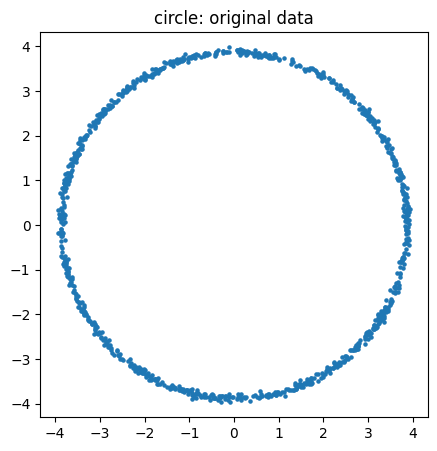

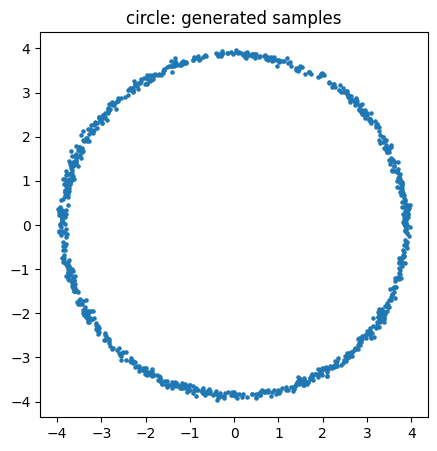

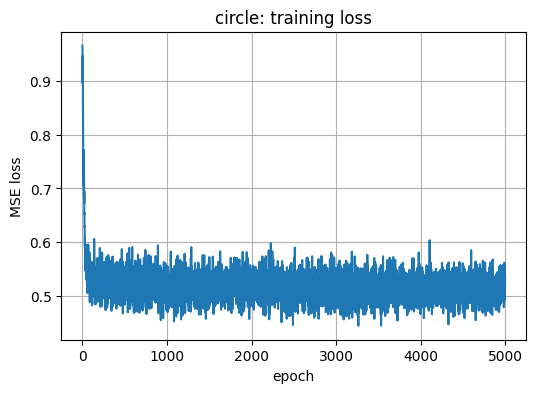


========== dinohead ==========
Loaded dinohead_pts.npy: (10240, 2)
alpha_bar_T = 0.04805843159556389
Epoch     0, loss = 0.779349
Epoch   500, loss = 0.556198
Epoch  1000, loss = 0.546208
Epoch  1500, loss = 0.542541
Epoch  2000, loss = 0.541842
Epoch  2500, loss = 0.543023
Epoch  3000, loss = 0.558821
Epoch  3500, loss = 0.541015
Epoch  4000, loss = 0.541050
Epoch  4500, loss = 0.538590


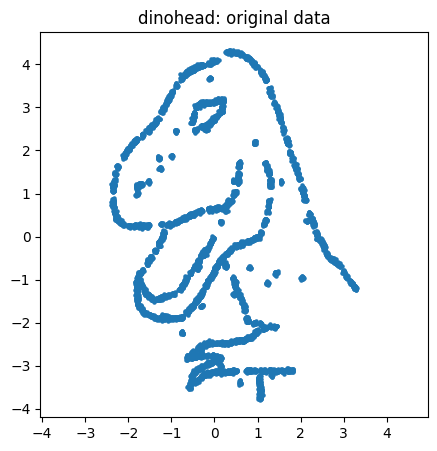

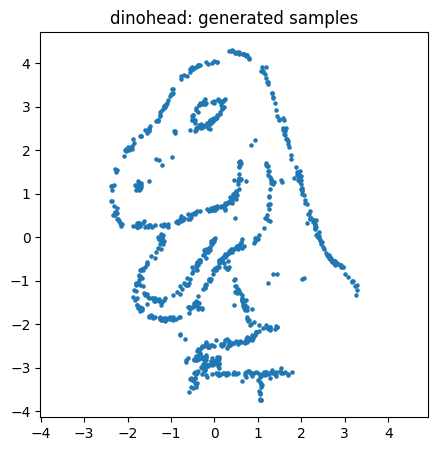

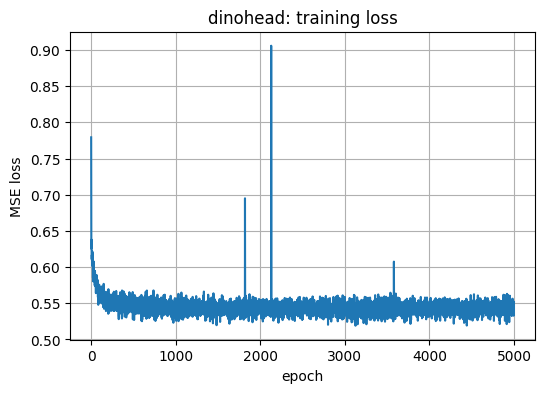


========== square ==========
Loaded square_pts.npy: (1000, 2)
alpha_bar_T = 0.04805843159556389
Epoch     0, loss = 0.925324
Epoch   500, loss = 0.589651
Epoch  1000, loss = 0.526028
Epoch  1500, loss = 0.529862
Epoch  2000, loss = 0.547458
Epoch  2500, loss = 0.528749
Epoch  3000, loss = 0.548321
Epoch  3500, loss = 0.524136
Epoch  4000, loss = 0.557925
Epoch  4500, loss = 0.532926


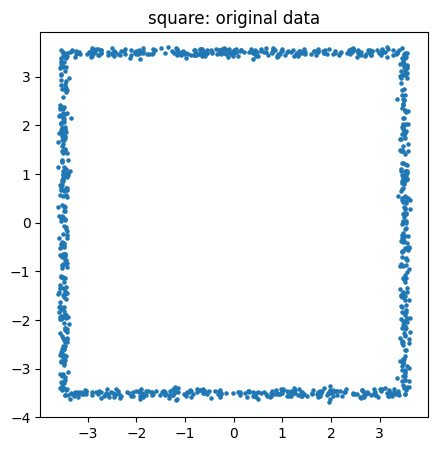

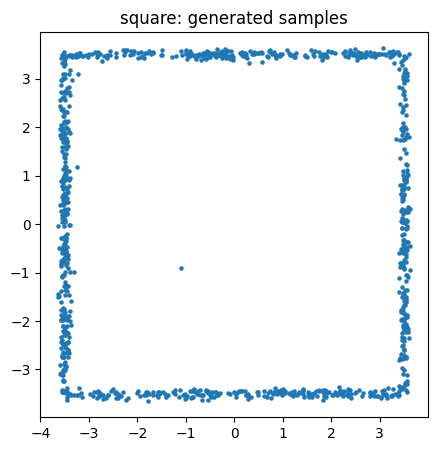

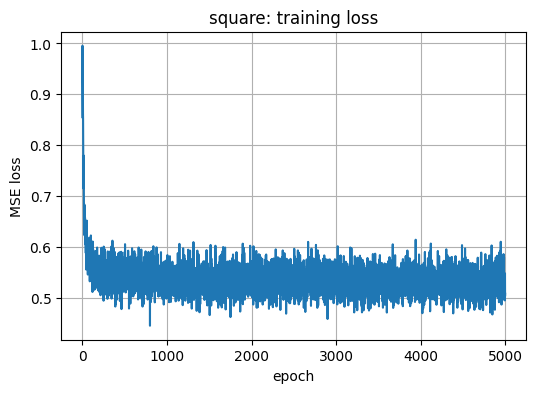